In [2]:
import pandas as pd

# generate irradiance

In [58]:
paths = ['/mnt/c/Users/Acer/Downloads/cabrobo2024.csv', '/mnt/c/Users/Acer/Downloads/cabrobo2025.csv']
all_dfs = []
for p in paths:
    df = pd.read_csv(p, sep=';', decimal = ',')
    df= df[((df['Hora (UTC)'] >=900) & (df['Hora (UTC)'] <=2100))]
    df['date'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
    df = df.sort_values(['date', 'Hora (UTC)' ])
    display(df['Radiacao (KJ/m²)'].isna().value_counts())
    df['Radiacao (KJ/m²)'] = df['Radiacao (KJ/m²)'].interpolate()
    all_dfs.append(df[['date', 'Hora (UTC)','Radiacao (KJ/m²)']])

pd.concat(all_dfs).rename(columns={'Radiacao (KJ/m²)':'y'})['y'].to_csv('cabrobo.txt', index=False)
pd.concat(all_dfs).shape

Radiacao (KJ/m²)
False    4755
True        3
Name: count, dtype: int64

Radiacao (KJ/m²)
False    4646
True       99
Name: count, dtype: int64

(9503, 3)

# wind speed

In [10]:
paths = ['/home/domingossj/Downloads/campinagrandehour.csv']
all_dfs = []
for p in paths:
    df = pd.read_csv(p, sep=';', decimal = ',')
    
    df['date'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
    df = df.sort_values(['date', 'Hora (UTC)' ])
    display(df['Vel. Vento (m/s)'].isna().value_counts(normalize=True))
    df['Vel. Vento (m/s)'] = df['Vel. Vento (m/s)'].interpolate()
    all_dfs.append(df[['date', 'Hora (UTC)','Vel. Vento (m/s)']])

pd.concat(all_dfs).rename(columns={'Vel. Vento (m/s)':'y'})['y'].to_csv('windspeedcampinagrandehour.txt', index=False)
pd.concat(all_dfs).shape

False    0.915525
True     0.084475
Name: Vel. Vento (m/s), dtype: float64

(8760, 3)

/home/domingossj/experiments/.venv/lib/python3.10/site-packages/statsmodels/tools/tools.py:6: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.23.2)
  import scipy.linalg


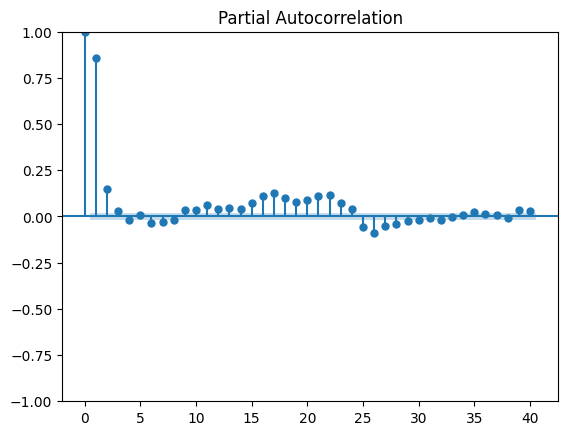

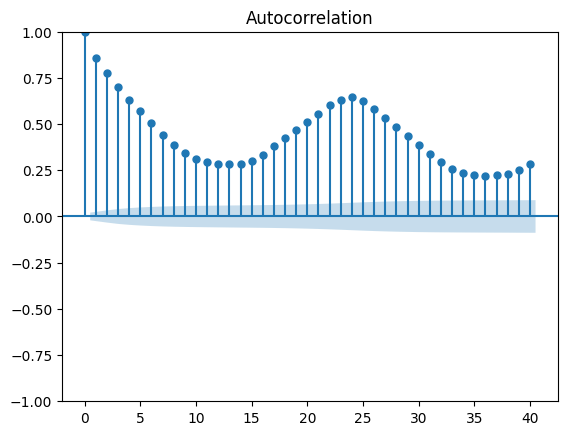

In [4]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
ts = pd.concat(all_dfs).rename(columns={'Vel. Vento (m/s)':'y'})['y']
plot_pacf(ts)
plt.show()
plot_acf(ts)
plt.show()